# Getting started with pyfunkyheatmap

Python port of the [Getting started](https://funkyheatmap.github.io/funkyheatmap/articles/funkyheatmap.html) R vignette.

We will use the classic `mtcars` dataset to showcase how to use **pyfunkyheatmap**, gradually adding features to the plot to show how to customise it.

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyfunkyheatmap import funky_heatmap, position_arguments

matplotlib.rcParams['figure.dpi'] = 110

## Loading the data

First, we load `mtcars`. We move the row names to a column named `id`, as
that is required by **pyfunkyheatmap** to display the row labels. We then
sort by the `mpg` column in descending order and keep the top 30 rows.

In [2]:
mtcars = pd.read_csv('../data/vignettes/mtcars.csv').rename(columns={'Unnamed: 0':'id'})
data = mtcars.sort_values('mpg', ascending=False).head(30).reset_index(drop=True)
data.head()

,id,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
1,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
2,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2
3,Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
4,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1


We can plot this data frame without any additional formatting, though it doesn't look very nice:

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


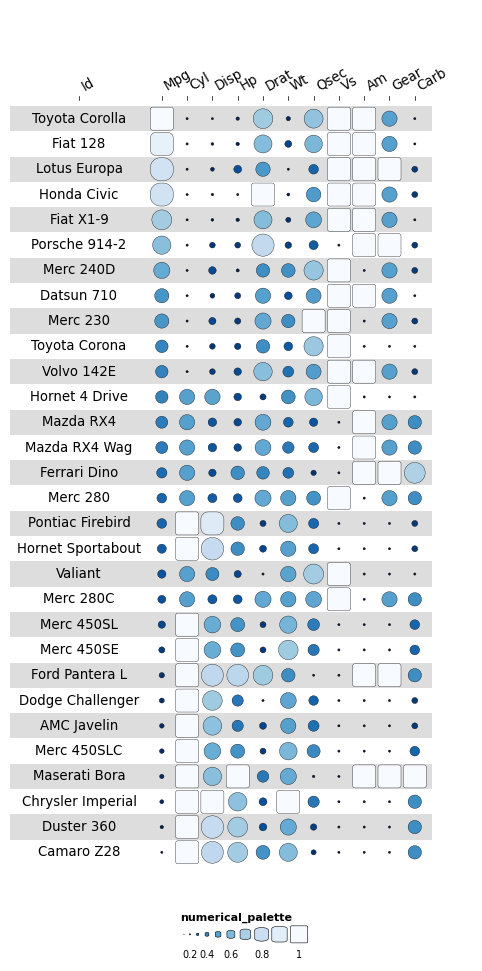

In [3]:
funky_heatmap(data)

## Adding `column_info`

We can add column information to the heatmap by specifying the `column_info`
argument. This should be a `DataFrame` with one row per heatmap column. The
required column is `id` (the data column to plot). All other columns are
optional and control the appearance.

If you want to group columns together (semantically related, or any other
logical grouping), specify the `group` column in `column_info`.

In [4]:
def opts(**kw): return json.dumps(kw)

cinfo = pd.DataFrame({
    'id': data.columns,
    'group': [None, 'Overall', 'Engine', 'Engine', 'Engine', 'Transmission',
              'Overall', 'Performance', 'Engine', 'Transmission',
              'Transmission', 'Engine'],
    'options': ['{}'] * 12,
})
cinfo

,id,group,options
0,id,None,{}
1,mpg,Overall,{}
2,cyl,Engine,{}
3,disp,Engine,{}
4,hp,Engine,{}
5,drat,Transmission,{}
6,wt,Overall,{}
7,qsec,Performance,{}
8,vs,Engine,{}
9,am,Transmission,{}


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


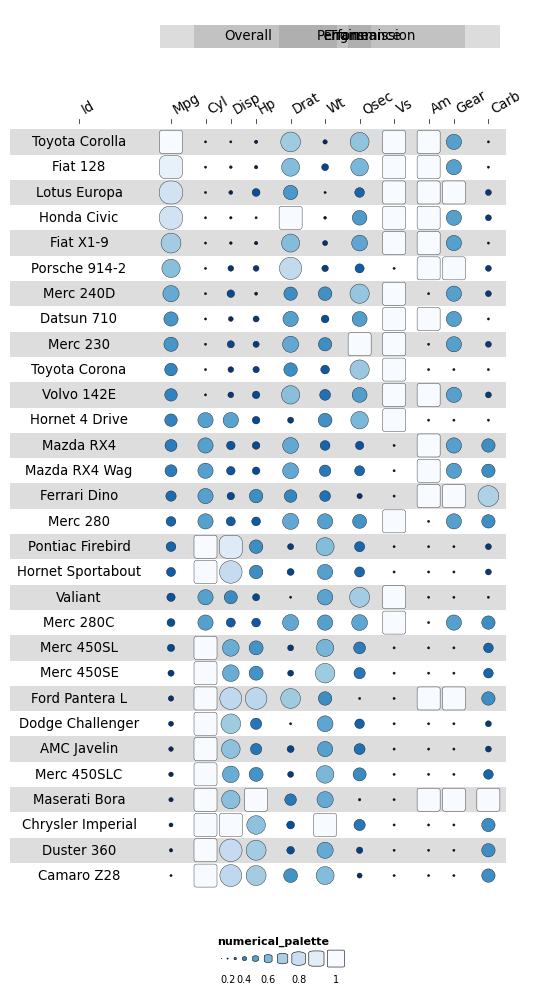

In [5]:
funky_heatmap(data, column_info=cinfo)

We can see that this doesn't work directly: we need to manually rearrange
the columns so that columns in the same group are adjacent to each other.

In [6]:
data = data[['id','qsec','mpg','wt','cyl','carb','disp','hp','vs','drat','am','gear']]

cinfo = pd.DataFrame({
    'id': data.columns,
    'group': [None, 'Performance', 'Overall', 'Overall',
              'Engine', 'Engine', 'Engine', 'Engine', 'Engine',
              'Transmission', 'Transmission', 'Transmission'],
    'options': ['{}'] * 12,
})
cinfo

,id,group,options
0,id,None,{}
1,qsec,Performance,{}
2,mpg,Overall,{}
3,wt,Overall,{}
4,cyl,Engine,{}
5,carb,Engine,{}
6,disp,Engine,{}
7,hp,Engine,{}
8,vs,Engine,{}
9,drat,Transmission,{}


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


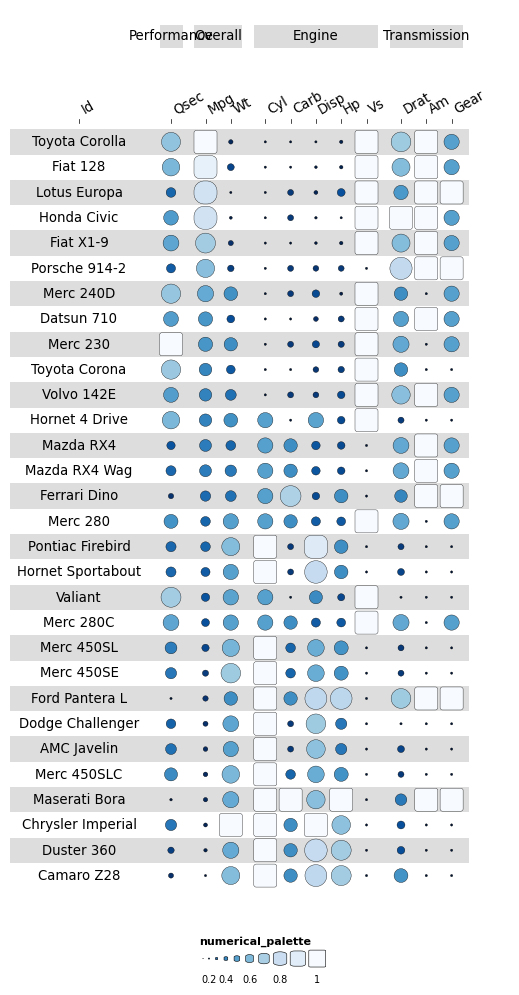

In [7]:
funky_heatmap(data, column_info=cinfo)

We should probably also add a `name` column, to make the column labels more informative.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


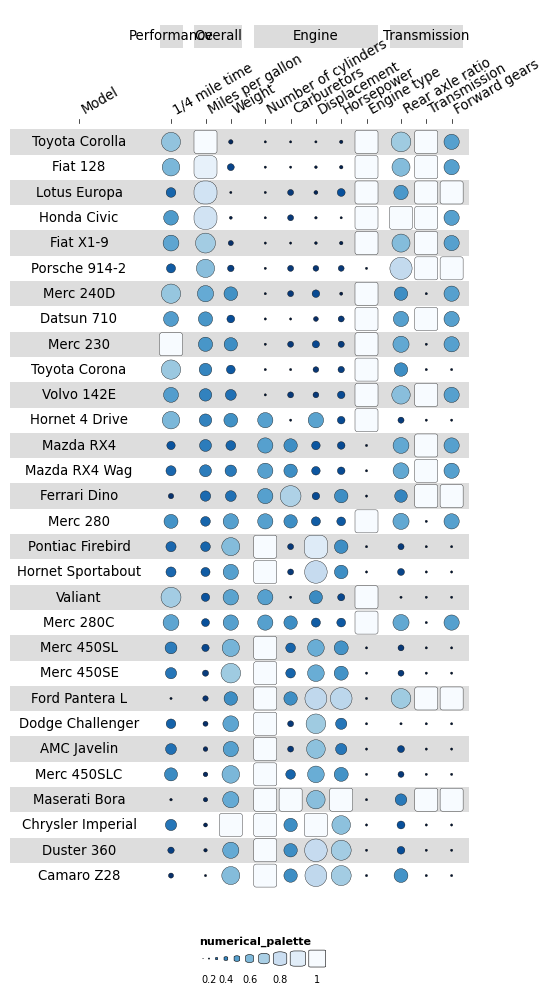

In [8]:
cinfo['name'] = ['Model','1/4 mile time','Miles per gallon','Weight',
                 'Number of cylinders','Carburetors','Displacement','Horsepower',
                 'Engine type','Rear axle ratio','Transmission','Forward gears']
funky_heatmap(data, column_info=cinfo)

This is better — at least the column groups are readable now. The column
groups themselves aren't very distinct visually, though. We can fix that by
adding a `palette` column to `column_info`.

## Adding palettes

Adding a `palette` column on its own isn't enough — we also need to pass a
`palettes` dict, where keys correspond to the values in the `palette`
column and values are one of the predefined palettes:

For numerical data: `Blues`, `Reds`, `Greens`, `YlOrBr`, `Greys`.

For categorical data: `Set1`, `Set2`, `Set3`, `Dark2`.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


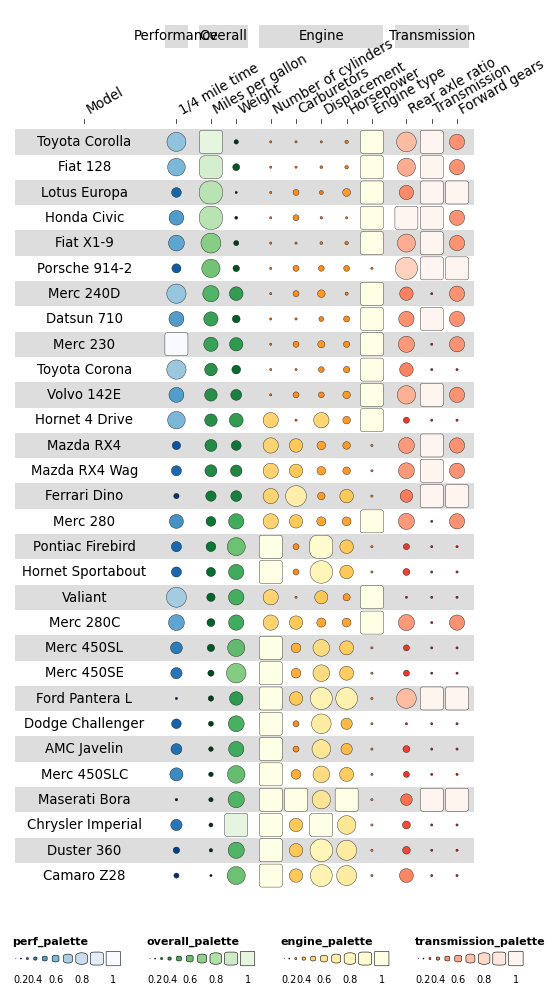

In [9]:
cinfo['palette'] = [None, 'perf_palette',
                    'overall_palette', 'overall_palette',
                    'engine_palette', 'engine_palette', 'engine_palette',
                    'engine_palette', 'engine_palette',
                    'transmission_palette', 'transmission_palette', 'transmission_palette']

palettes = {
    'perf_palette':         'Blues',
    'overall_palette':      'Greens',
    'engine_palette':       'YlOrBr',
    'transmission_palette': 'Reds',
}

funky_heatmap(data, column_info=cinfo, palettes=palettes)

## Adding `column_groups`

That's already a lot more visually distinct. It would be nice if we could
color the names of the column groups as well. We can do that by adding a
`column_groups` `DataFrame`.

It must have the following columns:
* `Category` (or any other label column) — the display name of the column group
* `group` — links each row to a `group` value in `column_info`
* `palette` — the palette to use for the column group

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


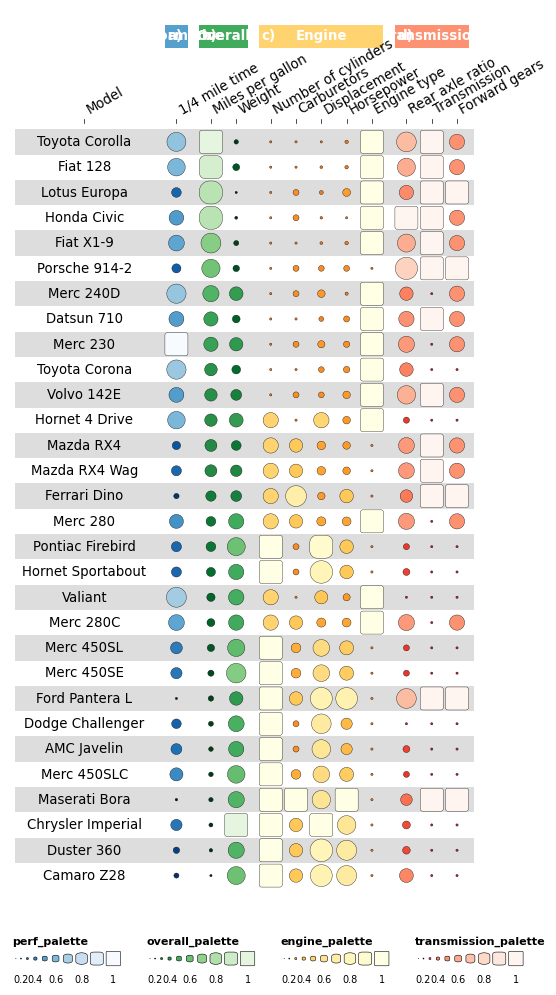

In [10]:
column_groups = pd.DataFrame({
    'Category': ['Performance','Overall','Engine','Transmission'],
    'group':    ['Performance','Overall','Engine','Transmission'],
    'palette':  ['perf_palette','overall_palette','engine_palette','transmission_palette'],
})
funky_heatmap(data, column_info=cinfo, column_groups=column_groups, palettes=palettes)

## Specifying geoms

It makes sense to present some information differently. The number of
cylinders and carburetors are discrete values, so let's display them as
rectangles with a text overlay.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


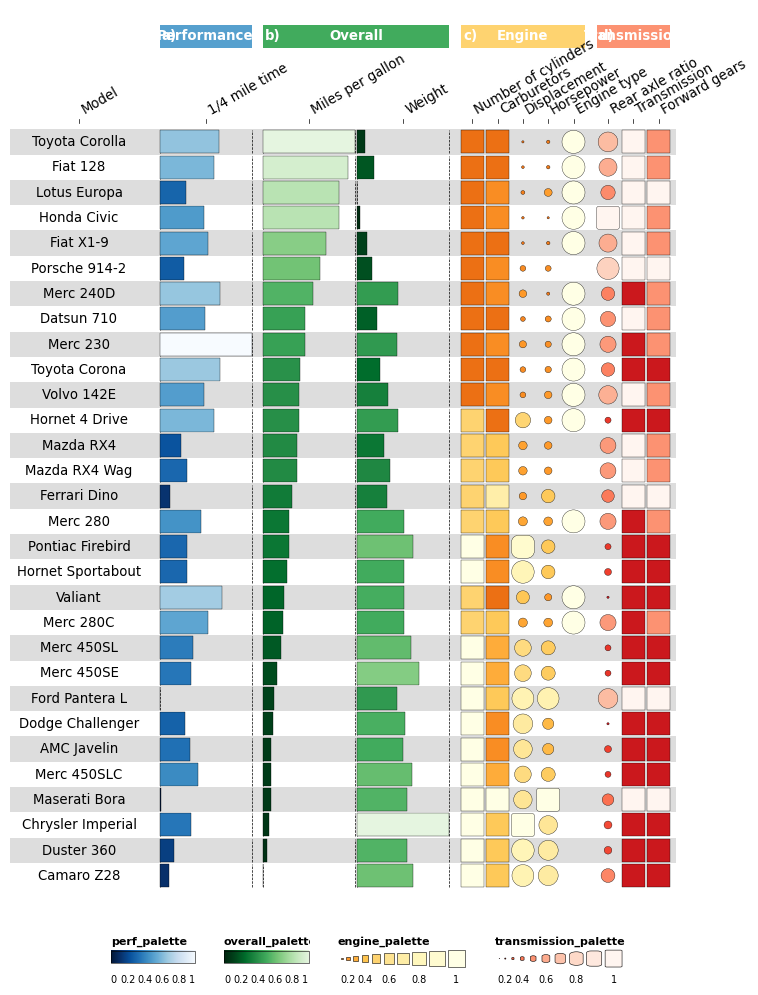

In [11]:
cinfo['geom'] = ['text','bar','bar','bar','rect','rect','funkyrect','funkyrect',
                 'circle','funkyrect','rect','rect']
funky_heatmap(data, column_info=cinfo, column_groups=column_groups, palettes=palettes)

This looks nice, but we don't have the text overlay yet — we add overlay text rows for the discrete columns.

In [12]:
def insert_overlay_at(df, *, before_iloc1, new_id, group, palette='black'):
    """Insert a text-overlay row referencing `new_id` at 1-indexed position
    `before_iloc1` (matches R's ``add_row(..., .before=N)``)."""
    pos = before_iloc1 - 1
    if pos >= len(df):
        pos = len(df)
    row = {
        'id': new_id, 'group': group, 'name': '', 'geom': 'text',
        'options': json.dumps({'overlay': True}), 'palette': palette,
    }
    return pd.concat(
        [df.iloc[:pos], pd.DataFrame([row]), df.iloc[pos:]],
        ignore_index=True,
    )

# R does these four .before= inserts in order. Each shifts subsequent
# positions down by one.
cinfo = insert_overlay_at(cinfo, before_iloc1=6,  new_id='cyl',  group='Engine')
cinfo = insert_overlay_at(cinfo, before_iloc1=8,  new_id='carb', group='Engine')
cinfo = insert_overlay_at(cinfo, before_iloc1=14, new_id='am',   group='Transmission')
cinfo = insert_overlay_at(cinfo, before_iloc1=17, new_id='gear', group='Transmission')

palettes['black'] = ['black', 'black']
cinfo

,id,group,options,name,palette,geom
0,id,None,{},Model,None,text
1,qsec,Performance,{},1/4 mile time,perf_palette,bar
2,mpg,Overall,{},Miles per gallon,overall_palette,bar
3,wt,Overall,{},Weight,overall_palette,bar
4,cyl,Engine,{},Number of cylinders,engine_palette,rect
5,cyl,Engine,"{""overlay"": true}",,black,text
6,carb,Engine,{},Carburetors,engine_palette,rect
7,carb,Engine,"{""overlay"": true}",,black,text
8,disp,Engine,{},Displacement,engine_palette,funkyrect
9,hp,Engine,{},Horsepower,engine_palette,funkyrect


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


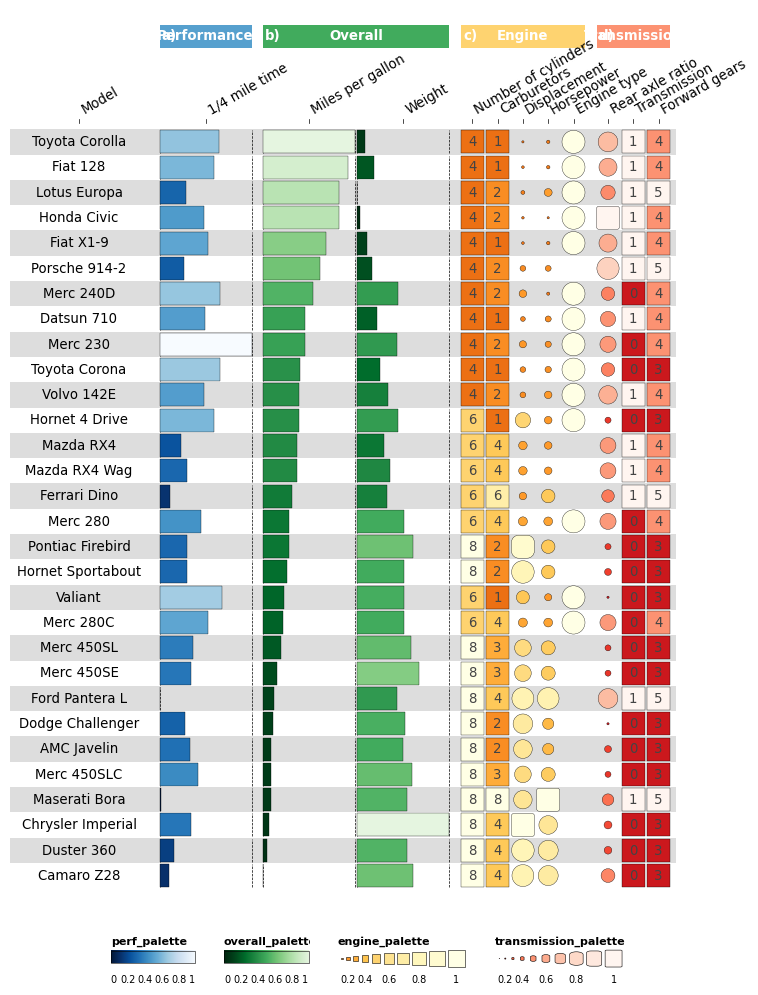

In [13]:
funky_heatmap(data, column_info=cinfo, column_groups=column_groups, palettes=palettes)

This is starting to look like a nice visualisation.

## Customising legends

We can customise the legends for each palette. If we want multiple legends
for one palette, just include multiple `legends` entries pointing to it.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


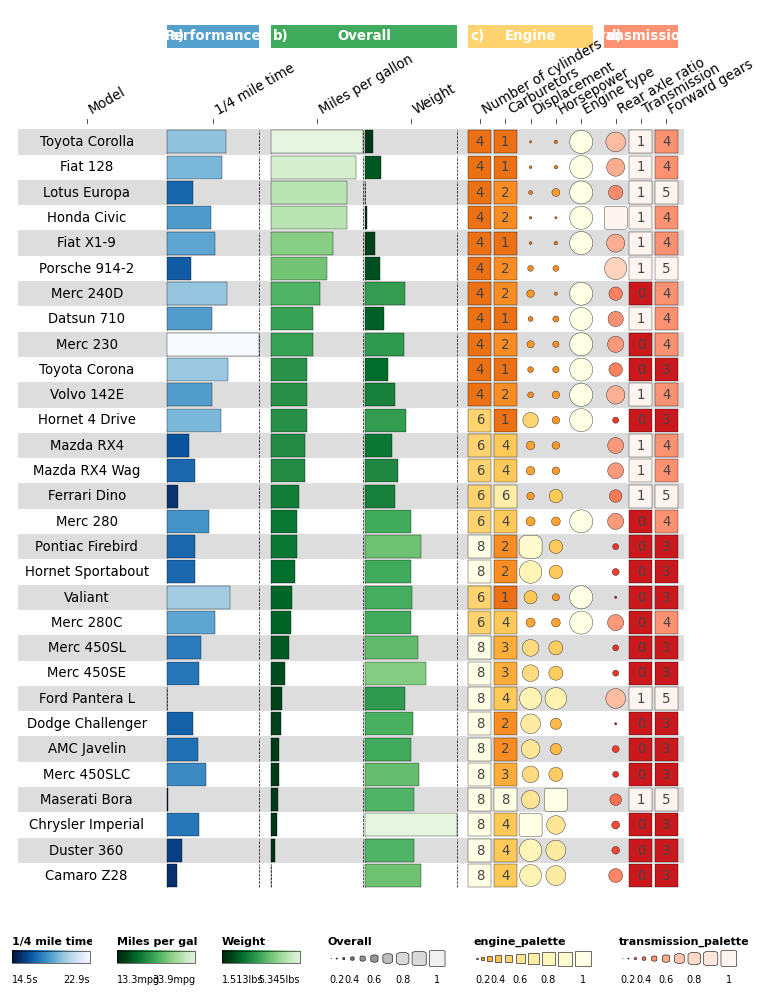

In [14]:
# verbatim RColorBrewer Greys, reversed and without the lightest stop
greys9_rev = list(reversed(['#FFFFFF','#F0F0F0','#D9D9D9','#BDBDBD','#969696',
                            '#737373','#525252','#252525','#000000']))[:-1]
palettes['funky_palette_grey'] = greys9_rev

legends = [
    dict(palette='perf_palette',    geom='bar', title='1/4 mile time',
         labels=[f"{data['qsec'].min()}s"] + [''] * 8 + [f"{data['qsec'].max()}s"]),
    dict(palette='overall_palette', geom='bar', title='Miles per gallon',
         labels=[f"{data['mpg'].min()}mpg"] + [''] * 8 + [f"{data['mpg'].max()}mpg"]),
    dict(palette='overall_palette', geom='bar', title='Weight',
         labels=[f"{data['wt'].min()}lbs"]  + [''] * 8 + [f"{data['wt'].max()}lbs"]),
    dict(palette='funky_palette_grey', geom='funkyrect', title='Overall', enabled=True,
         labels=['0','','0.2','','0.4','','0.6','','0.8','','1']),
]
funky_heatmap(data, column_info=cinfo, column_groups=column_groups,
              palettes=palettes, legends=legends)

We can disable the `engine_palette` and `transmission_palette` legends by
adding entries with `enabled=False` — they don't add extra information now
that the columns are already colour-coded.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


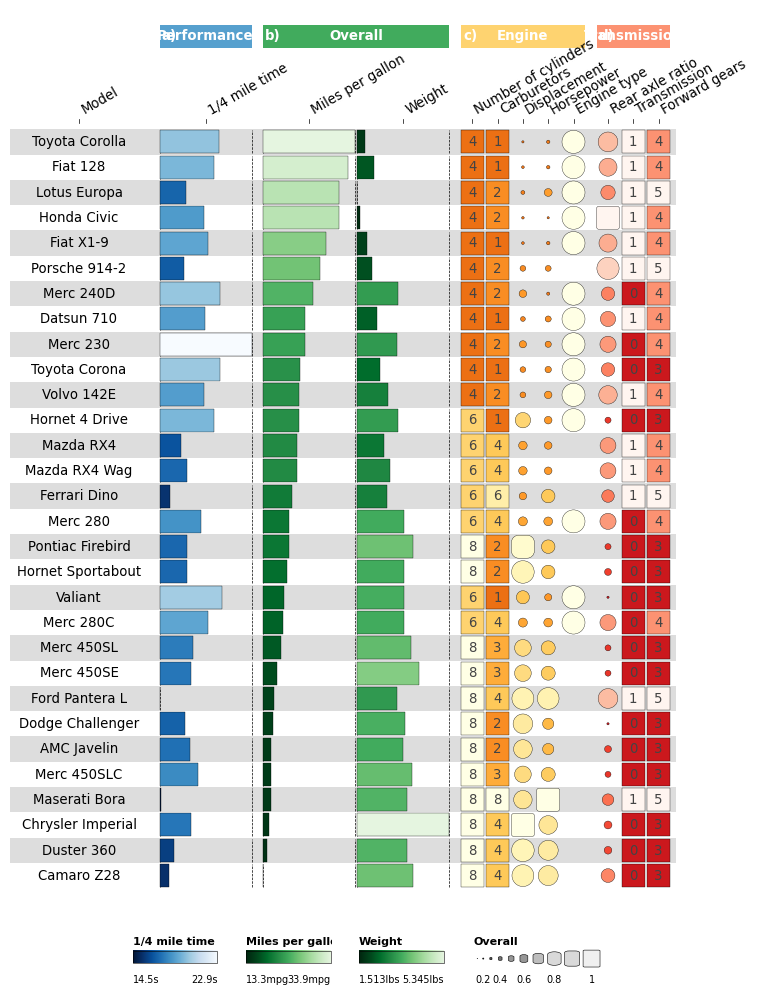

In [15]:
disabled_legends = [
    dict(palette='engine_palette',       enabled=False),
    dict(palette='transmission_palette', enabled=False),
]
legends = legends + disabled_legends
funky_heatmap(data, column_info=cinfo, column_groups=column_groups,
              palettes=palettes, legends=legends)

## Adding images

The `transmission` and `engine type` columns are still uninformative —
they just contain 0/1. Let's replace those values with images. First we
remap the data values to image names, then we set the image directory and
extension via `column_info`.

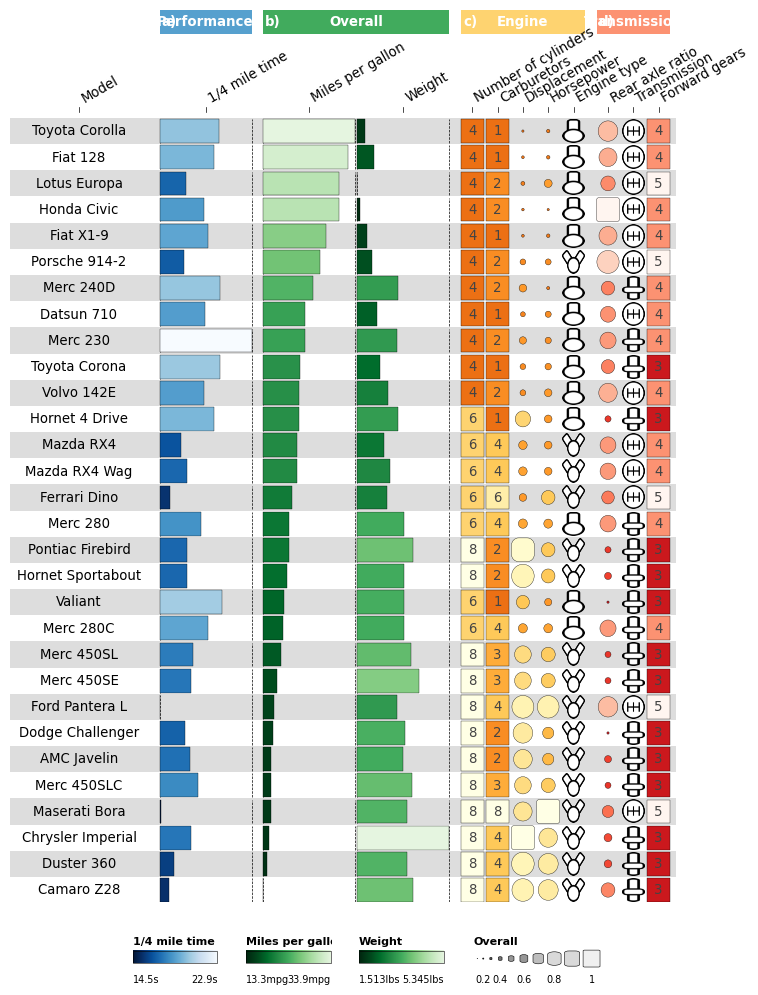

In [16]:
data = data.copy()
data['am'] = data['am'].map({0: 'automatic', 1: 'manual'}).astype(str)
data['vs'] = data['vs'].map({0: 'vengine',  1: 'straight'}).astype(str)

cinfo = cinfo.copy()
cinfo['directory'] = None
cinfo['extension'] = None

# R: `cinfo <- cinfo[-14, ]` — drop the 14th 1-indexed row (the `am` overlay
# inserted earlier). Iloc 13 in Python.
cinfo = cinfo.reset_index(drop=True)
cinfo = cinfo.drop(index=13).reset_index(drop=True)

mask = cinfo['id'].isin(['vs', 'am'])
cinfo.loc[mask, 'directory'] = 'images'
cinfo.loc[mask, 'extension'] = 'png'
# R: `cinfo[c(11,13),"geom"] <- "image"` — 1-indexed rows 11 (vs) and 13 (am).
cinfo.loc[[10, 12], 'geom'] = 'image'

funky_heatmap(data, column_info=cinfo, column_groups=column_groups,
              palettes=palettes, legends=legends)

## Row grouping

We can group rows together too. Let's highlight the Mercedes cars. We
rearrange the data so the Mercedes rows are at the top and pass a
`row_info` / `row_groups` pair.

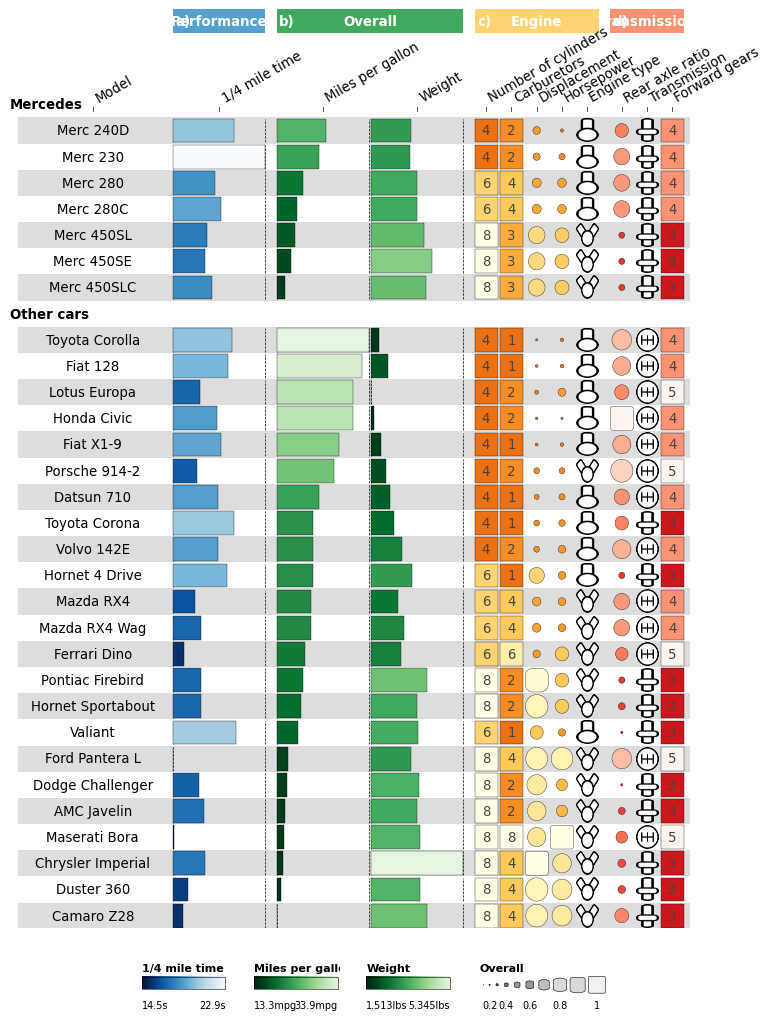

In [17]:
row_info = pd.DataFrame({
    'id':    data['id'].to_numpy(),
    'group': ['Mercedes' if 'Merc' in str(x) else 'Other' for x in data['id']],
})
order = row_info['group'].argsort(kind='mergesort')
data = data.iloc[order].reset_index(drop=True)
row_info = row_info.iloc[order].reset_index(drop=True)

row_groups = pd.DataFrame({
    'level1': ['Mercedes', 'Other cars'],
    'group':  ['Mercedes', 'Other'],
})

funky_heatmap(data, column_info=cinfo, column_groups=column_groups,
              palettes=palettes, legends=legends,
              row_info=row_info, row_groups=row_groups)

Some final spacing tweaks: e.g. the `Transmission` column group needs a
little more room. We can do this by setting `width` in the `options` of
the relevant rows in `column_info`.

If you still want to fine-tune things, save the figure as `.svg` and edit
in a vector graphics editor.

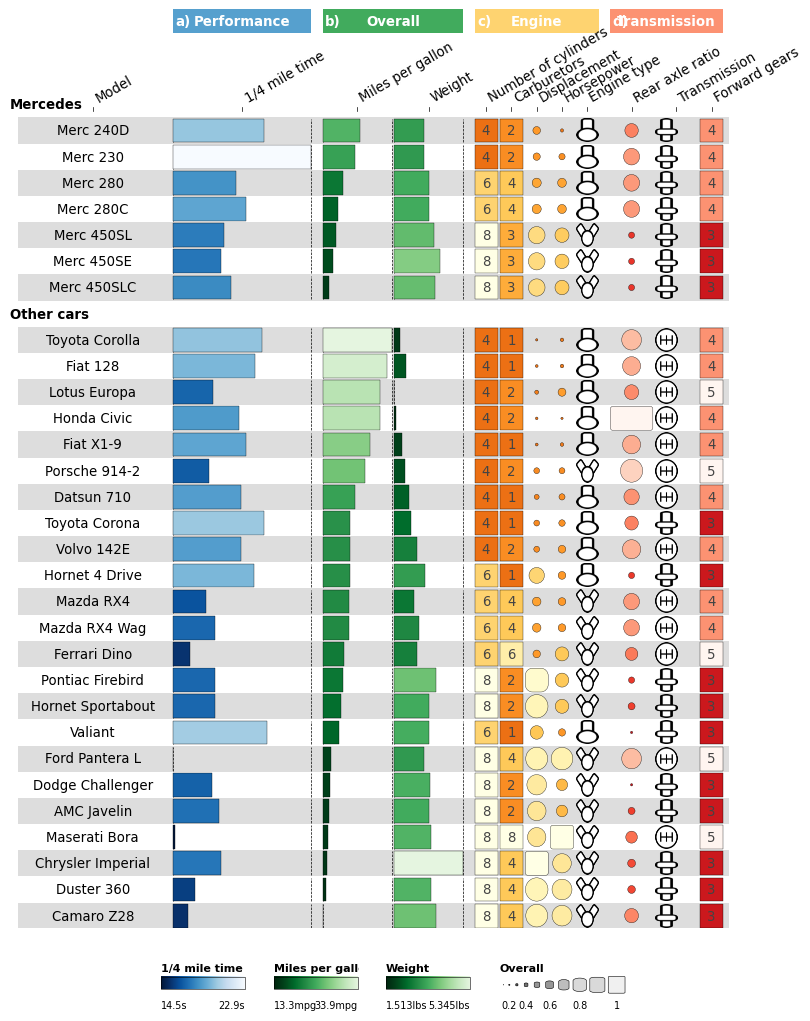

In [18]:
def set_option(df, iloc, **opts):
    o = json.loads(df.iloc[iloc]['options']) if df.iloc[iloc]['options'] else {}
    o.update(opts)
    df.at[iloc, 'options'] = json.dumps(o)
    return df

cinfo = cinfo.copy()
for i, w in [(0, 6), (1, 6), (2, 3), (3, 3), (11, 1.85), (12, 1.85)]:
    cinfo = set_option(cinfo, i, width=w)

fh = funky_heatmap(data, column_info=cinfo, column_groups=column_groups,
                   palettes=palettes, legends=legends,
                   row_info=row_info, row_groups=row_groups)
fh.save('../data/vignettes/getting_started_py.png', dpi=140, facecolor='white')
fh

## Side-by-side with the R reference

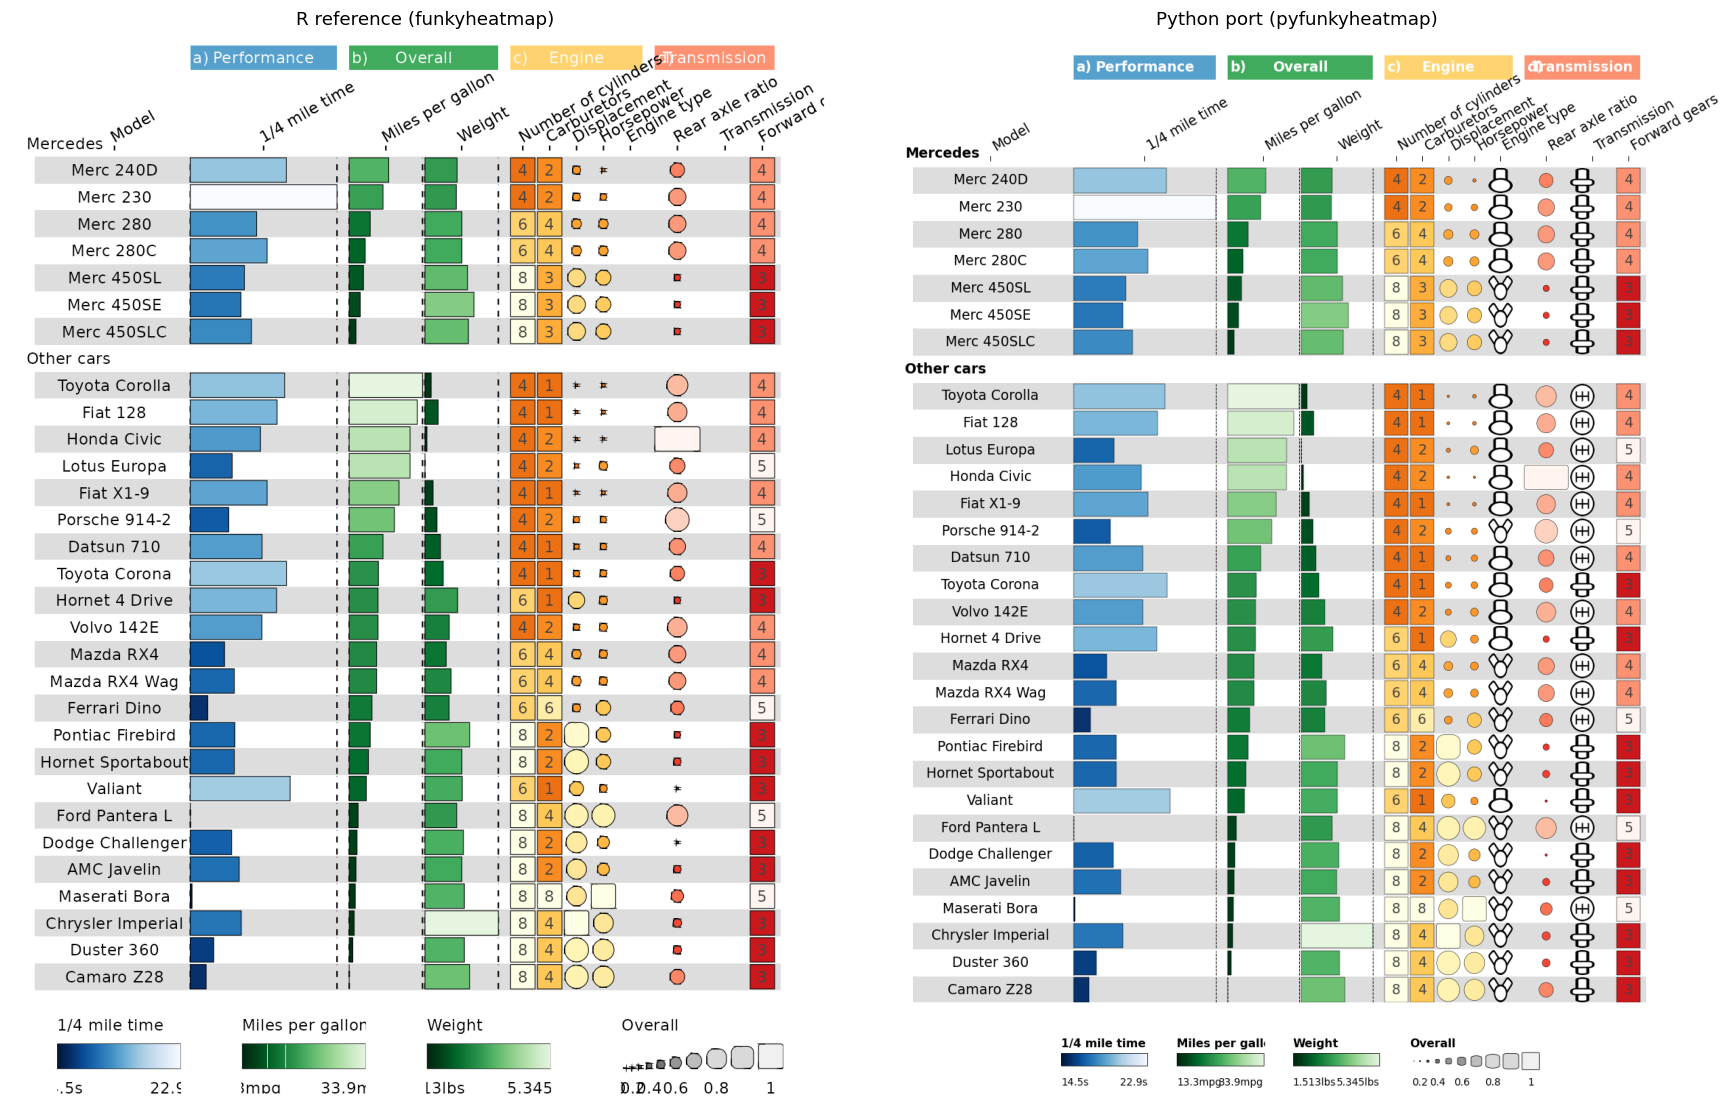

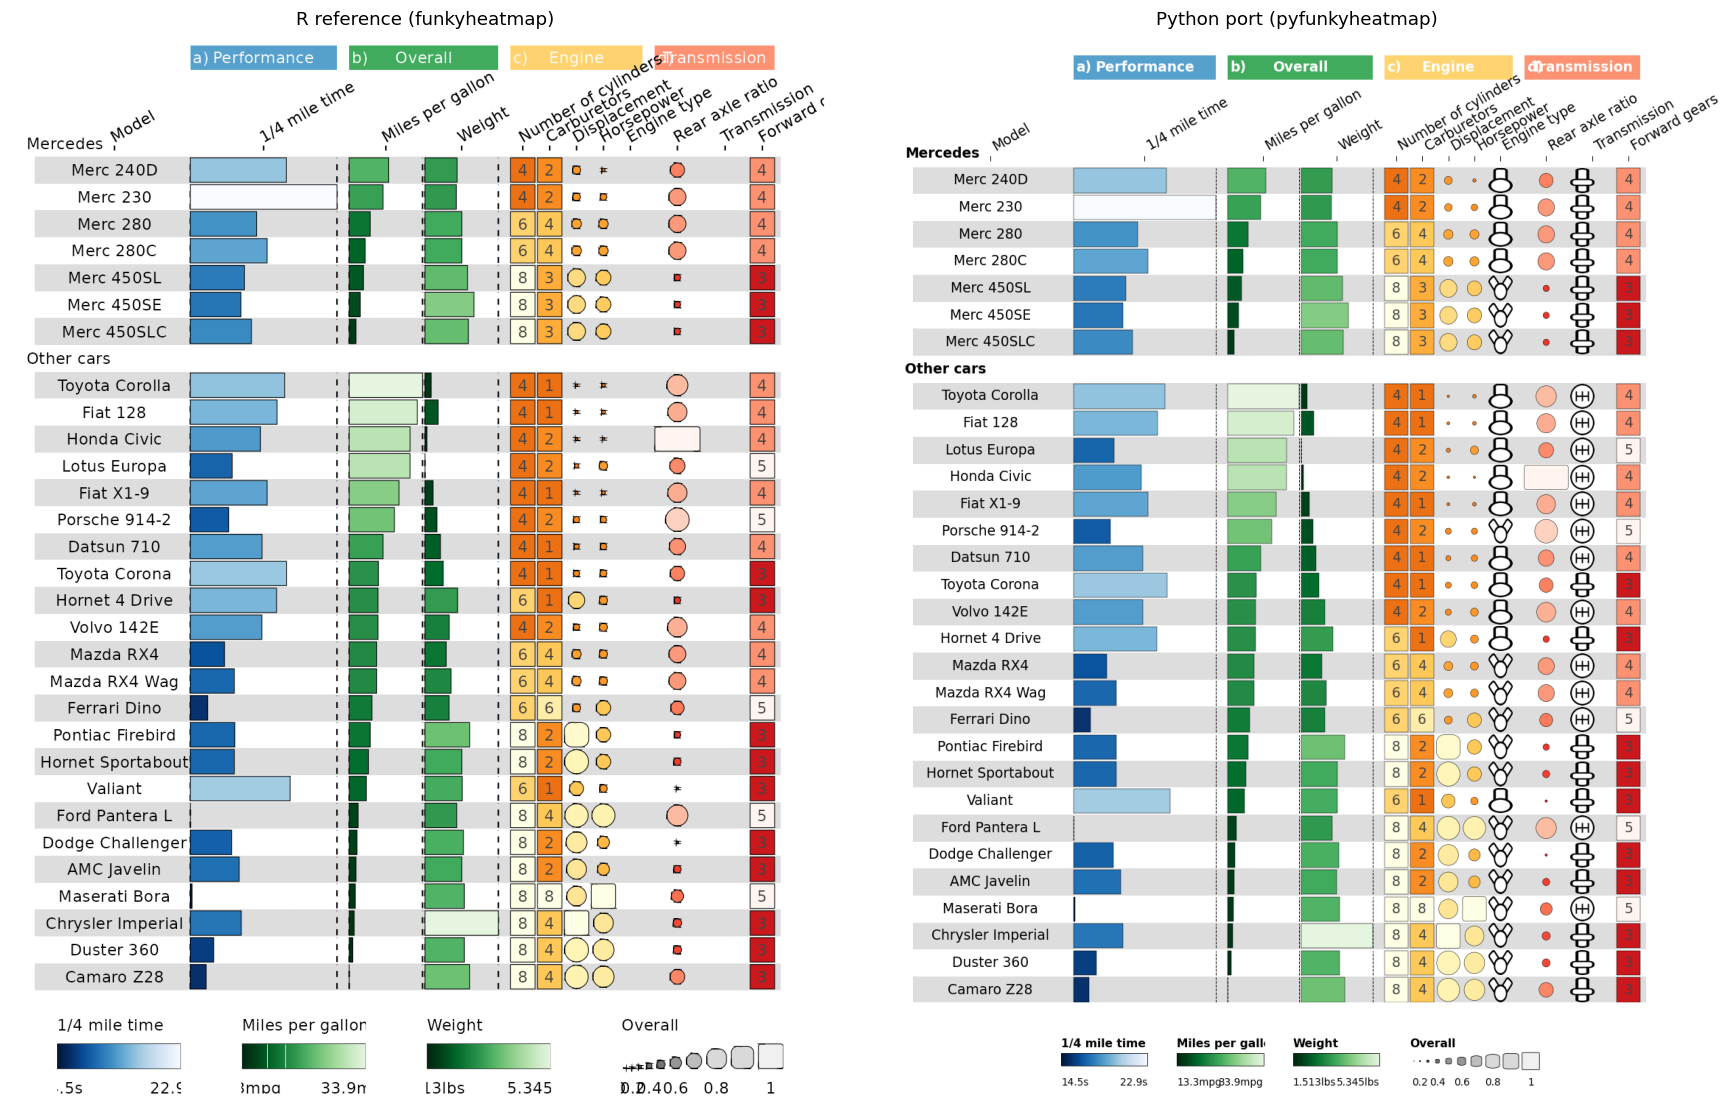

In [19]:
import matplotlib.image as mpimg
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes[0].imshow(mpimg.imread('../data/vignettes/getting_started_R.png'));  axes[0].set_title('R reference (funkyheatmap)',  fontsize=12); axes[0].axis('off')
axes[1].imshow(mpimg.imread('../data/vignettes/getting_started_py.png')); axes[1].set_title('Python port (pyfunkyheatmap)', fontsize=12); axes[1].axis('off')
plt.tight_layout()
fig

This is the same layout as the R vignette, built up one step at a time
from a bare `funky_heatmap(data)` call to the fully styled figure.